# Step 1 | Load and Inspect the Combined JSON (All Four Datasets)

### **What we are doing**
Reading the unified `OUTPUT_JSON_ALL_FOUR.json` that merges features from: <br>
- Heart Diagnoses  
- Laboratory Events  
- Microbiology Events  
- Procedure Codes  

### **Why we are doing it**
To analyze patients holistically across all available hospital data in a single feature matrix, enabling integrated clustering later.

In [22]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

with open("OUTPUT_JSON_ALL_FOUR.json", "r", encoding="utf-8") as f:
    data_all = json.load(f)

print("Keys:", data_all.keys())
print("Number of subjects:", len(data_all.get("subjects", {})))

Keys: dict_keys(['created_at', 'subjects'])
Number of subjects: 4576


# Step 2 | Flatten JSON → Feature DataFrame

### **What we are doing**
Extracting per‑patient summary values from nested dictionaries (heart, microbiology, lab, procedure) into a flat table.

### **Why we are doing it**
Machine‑learning models and clustering algorithms require a numeric tabular format.  
Flattening converts complex JSON profiles into one row = one patient.

In [2]:
rows = []

for sid, sdata in data_all["subjects"].items():
    row = {"subject_id": sid}

    # --- Heart features ---
    heart_dict = sdata.get("heart_dataset")
    if isinstance(heart_dict, dict):
        h = heart_dict.get("binary_findings_summary", {})
        row.update({
            f"heart_{k}": int(v) if isinstance(v, bool) else v
            for k, v in h.items()
            if isinstance(v, (int, float, bool))
        })

    # --- Microbiology summary ---
    micro_dict = sdata.get("microbiology_dataset")
    if isinstance(micro_dict, dict):
        row["micro_n_records"] = micro_dict.get("n_records", 0)
        row["micro_num_sites"] = len(micro_dict.get("anatomical_site", []))

    # --- Laboratory data ---
    hadm_all = sdata.get("hadm_records_all")
    if isinstance(hadm_all, dict) and len(hadm_all) > 0:
        first = next(iter(hadm_all.values()))
        lab = first.get("lab_dataset", {}) or {}
        proc = first.get("procedure_dataset", {}) or {}
        for k, v in lab.items():
            row[f"lab_{k}"] = v
        for k, v in proc.items():
            row[f"proc_{k}"] = v

    rows.append(row)

df_all = pd.DataFrame(rows).fillna(0)
print("Shape:", df_all.shape)

Shape: (4576, 173)


# Step 3 | Data Cleaning and Pruning

### **What we are doing**
1. Remove non‑numeric identifiers.  
2. Convert all features to numeric.  
3. Reduce redundant or constant columns using correlation and variance analysis.

### **Why we are doing it**
Simplifies data while preserving useful variance and prevents duplicated information from biasing clustering results.

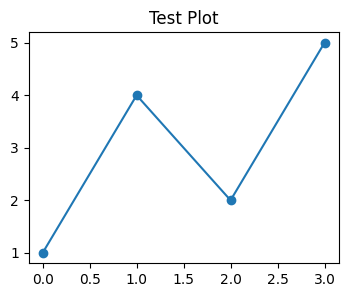

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
plt.plot([0,1,2,3],[1,4,2,5], marker='o')
plt.title("Test Plot")
plt.show()  # ensures the plot is rendered inline

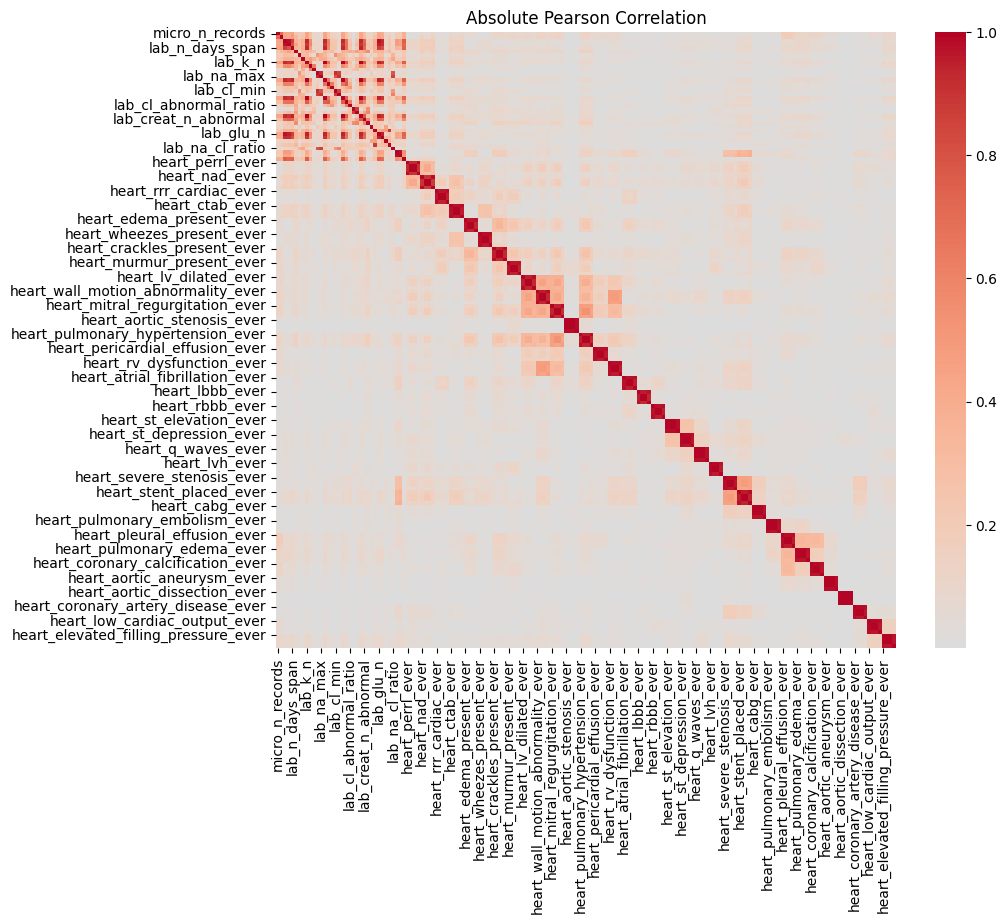

In [4]:
X = df_all.drop(columns=["subject_id"])
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

corr = X.corr().abs()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Absolute Pearson Correlation")
plt.show()

In [5]:
high_corr = {corr.columns[j] for i in range(len(corr.columns)) for j in range(i) if corr.iloc[i,j] > 0.95}
X = X.drop(columns=list(high_corr), errors='ignore')

sel = VarianceThreshold(threshold=0.0)
sel.fit(X)
X = X.loc[:, sel.get_support()]
print("Final feature count:", X.shape[1])

Final feature count: 77


# Step 4 | K‑Means Clustering

### **What we are doing**
Cluster patients by overall similarity across all medical features.  
Determining the optimal *k* by elbow and silhouette methods.

### **Why we are doing it**
To identify distinct patient groups—e.g., stable cases, infection‑heavy, cardiorenal, surgical, and critical care profiles—without any predefined labels.

Best k: 3  | Max Silhouette: 0.6662312323983647


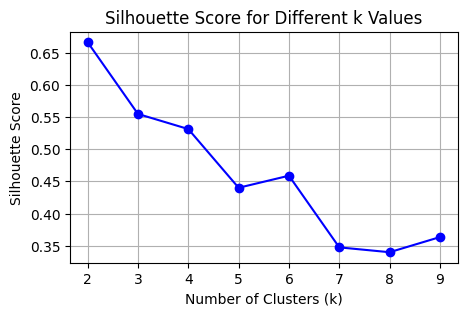

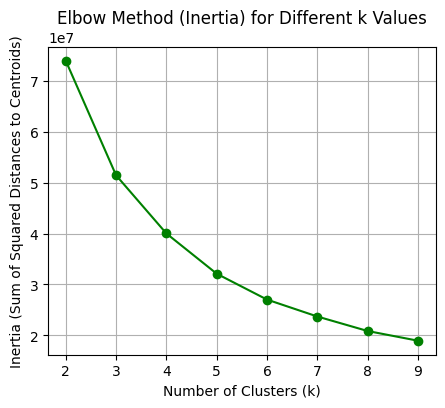

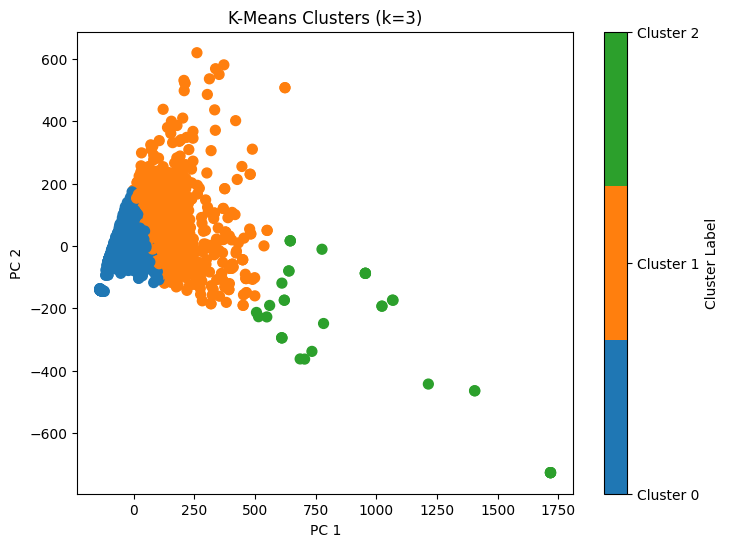

In [97]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from matplotlib.colors import ListedColormap

# Initialize k-values and silhouette list
k_values = range(2, 10)
sil = []
inertia = []

# Loop through different k values
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    sil.append(silhouette_score(X, labels))
    inertia.append(km.inertia_)  # Elbow method: sum of squared distances to centers

# Find the best k with the maximum silhouette score
best_k = 3  # k_values[int(np.argmax(sil))]
print("Best k:", best_k, " | Max Silhouette:", max(sil))

# Final KMeans model with optimal k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans_final.fit_predict(X)

# 1. Plotting Silhouette Scores for Different k
plt.figure(figsize=(5, 3))
plt.plot(k_values, sil, marker='o', linestyle='-', color='b')
plt.title("Silhouette Score for Different k Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# 2. Elbow Plot (Sum of Squared Distances)
plt.figure(figsize=(5, 4))
plt.plot(k_values, inertia, marker='o', linestyle='-', color='g')
plt.title("Elbow Method (Inertia) for Different k Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances to Centroids)")
plt.grid(True)
plt.show()

# 3. PCA Plot for Clusters (with best k)
pca = PCA(n_components=2)  # Use 2 components for 2D PCA visualization
reduced = pca.fit_transform(X)

# Create a discrete colormap with as many colors as there are clusters
cmap = ListedColormap(plt.cm.tab10.colors[:best_k])  # Slice to only take the first 'best_k' colors

# Plotting the PCA scatter plot for clusters
plt.figure(figsize=(8, 6))
sc = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap=cmap, s=50)
plt.title(f"K-Means Clusters (k={best_k})")
plt.xlabel("PC 1")
plt.ylabel("PC 2")

# Adding colorbar (showing cluster label)
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Label")
cbar.set_ticks([i for i in range(best_k)])  # Only show integer ticks for each cluster
cbar.set_ticklabels([f"Cluster {i}" for i in range(best_k)])  # Custom tick labels

plt.show()

/var/folders/sk/8mqn0wks7jg65xrftstzlxvw0000gp/T/ipykernel_20476/3016070559.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(tick_labels)  # Set the tick labels to include the size of each cluster


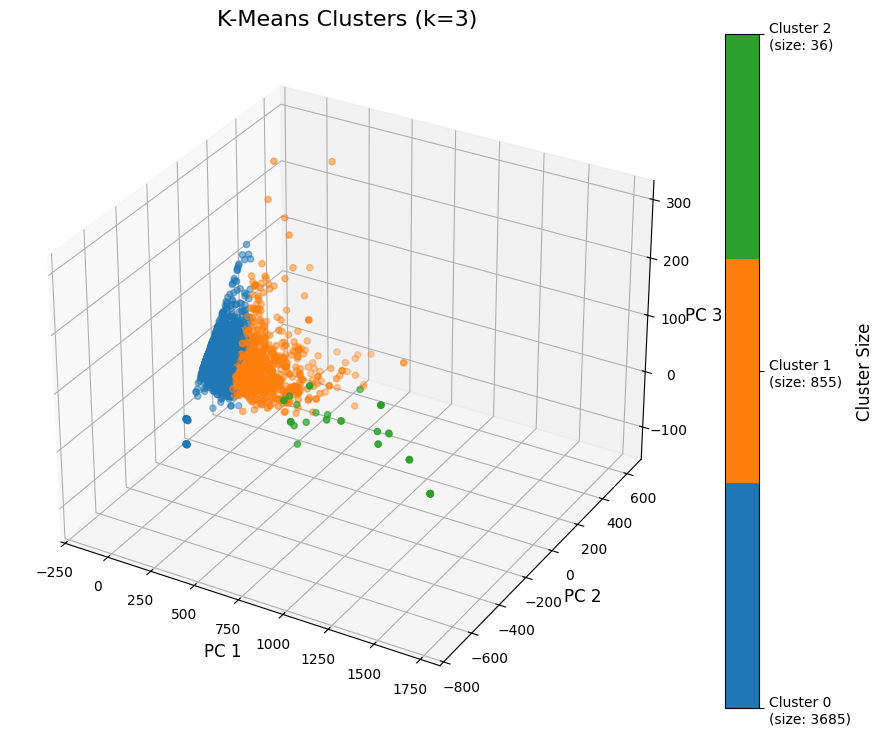

In [95]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator
import numpy as np

# 3D PCA Plot for Clusters (with best k)
pca = PCA(n_components=3)
reduced = pca.fit_transform(X)

# Calculate the size of each cluster
cluster_sizes = [np.sum(labels == i) for i in range(best_k)]  # Count data points in each cluster

# Create a discrete colormap with as many colors as there are clusters
cmap = ListedColormap(plt.cm.tab10.colors[:best_k])  # Slice to only take the first 'best_k' colors

# Increase figure size
fig = plt.figure(figsize=(12, 8))  # Larger figure

# Add 3D subplot
ax = fig.add_subplot(111, projection='3d')

# Plot the scatter, using the new discrete colormap
sc = ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], c=labels, cmap=cmap, s=20)

# Title and axis labels
plt.title(f"K-Means Clusters (k={best_k})", fontsize=16)
ax.set_xlabel("PC 1", fontsize=12)
ax.set_ylabel("PC 2", fontsize=12)
ax.set_zlabel("PC 3", fontsize=12)

# Colorbar with customized size labels (vertical on the side)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)  # Colorbar on the side
cbar.set_label("Cluster Size", fontsize=12)

# Customizing ticks and labels for the colorbar
tick_labels = [f"Cluster {i}\n(size: {cluster_sizes[i]})" for i in range(best_k)]  # Format ticks to include cluster size
cbar.set_ticks([i for i in range(best_k)])  # Set ticks to be integers (0, 1, 2, ..., k-1)
cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))  # Ensure ticks are integers
cbar.set_ticklabels(tick_labels)  # Set the tick labels to include the size of each cluster

# Adjust layout to make sure everything fits well, adding more padding to the top and bottom
plt.tight_layout(pad=3.0)  # Increase padding to avoid overlap

# Show the plot
plt.show()


# Step 5 | Cluster Interpretation

### **Visual meaning**
Each color represents one patient cluster.  
The separation in the PCA plot indicates distinct profiles. 
Examining cluster centroid values allows us to label them clinically.

### Note: We can get more medically descriptive as we increase the number of clusters. 

Now in the substeps below we will try to find out what these clusters are differentiated for.

### **What we are doing**
After assigning patients to clusters, we analyze which numeric features differ the most across these clusters.  
By computing the mean values per cluster and ranking features according to their variation, we can identify which laboratory, microbiological, or cardiac variables drive the separation between patient groups.

### **Why we are doing it**
This step helps us move beyond “black‑box” clustering results and understand **what makes each cluster distinct** in clinical terms.  
It highlights which characteristics—such as number of tests, abnormal values, or procedure counts—play the biggest role in distinguishing one cluster from another.

### **Explanation of the output**
- The printed list of “Top features differentiating clusters” shows variables with the largest mean differences between clusters.  
- The summary table (`display(...)`) transposes these values so we can easily compare how each cluster behaves for every important feature.

In [53]:
df_clustered = df_all.copy()
df_clustered["cluster"] = labels

# Ensure that only numeric columns are selected
numeric_columns = df_clustered.select_dtypes(include=[np.number]).columns

# Compute mean / median values of numeric features per cluster
cluster_summary = df_clustered[numeric_columns].groupby("cluster").mean()

# Optionally sort features by how strongly they differ between clusters
cluster_variation = cluster_summary.max() - cluster_summary.min()
important_features = cluster_variation.sort_values(ascending=False).head(20)

# Show the top changing features
print("Top features differentiating clusters:\n", important_features)

# Display summary table
display(cluster_summary[important_features.index].T)

Top features differentiating clusters:
 lab_total_tests           1896.803181
lab_n_invalid              980.044279
lab_glu_max                174.938052
lab_glu_n                   81.298809
lab_glu_n_abnormal          66.163893
lab_k_n                     64.598756
lab_na_n                    60.954839
lab_cl_n                    60.468679
lab_creat_n                 59.270586
lab_creat_n_abnormal        46.470194
lab_glu_var                 41.914749
lab_glu_min                 37.908480
lab_n_days_span             27.764624
lab_cl_n_abnormal           27.332941
lab_na_n_abnormal           24.037683
proc_n_days_span            23.310403
micro_n_records             21.273232
proc_total_procedures       14.701704
proc_unique_procedures      11.790268
lab_cl_min                  10.996751
dtype: float64


cluster,0,1,2
lab_total_tests,128.252374,401.378947,2025.055556
lab_n_invalid,42.122388,179.083041,1022.166667
lab_glu_max,141.117503,293.858480,316.055556
lab_glu_n,5.478969,17.794152,86.777778
lab_glu_n_abnormal,3.447218,14.712281,69.611111
lab_k_n,5.817910,17.487719,70.416667
lab_na_n,5.628494,17.063158,66.583333
lab_cl_n,5.614654,17.029240,66.083333
lab_creat_n,5.507191,16.619883,64.777778
lab_creat_n_abnormal,2.196472,10.597661,48.666667


### **Quick Feature Statistics per Cluster**
For the top 15 differentiating features, print concise descriptive statistics (mean, standard deviation, minimum, and maximum) for each cluster to verify the numerical spread and support medical interpretation of cluster characteristics.

In [47]:
for col in important_features.index[:15]:
    print(f"\n=== {col} ===")
    print(df_clustered.groupby("cluster")[col].describe()[["mean", "std", "min", "max"]])


=== lab_total_tests ===
                mean         std     min     max
cluster                                         
0         128.252374   90.310484     0.0   553.0
1         401.378947  246.626122    32.0  1372.0
2        2025.055556  826.240191  1107.0  3737.0

=== lab_n_invalid ===
                mean         std    min     max
cluster                                        
0          42.122388   36.338594    0.0   213.0
1         179.083041  119.060939    6.0   591.0
2        1022.166667  442.432400  619.0  1941.0

=== lab_glu_max ===
               mean         std    min    max
cluster                                      
0        141.117503   44.188270    0.0  310.0
1        293.858480  111.088546  119.0  900.0
2        316.055556  124.753458  132.0  497.0

=== lab_glu_n ===
              mean        std   min    max
cluster                                   
0         5.478969   4.322994   0.0   31.0
1        17.794152  11.700386   1.0   71.0
2        86.777778  33.44

## Plotting this to get a better understanding

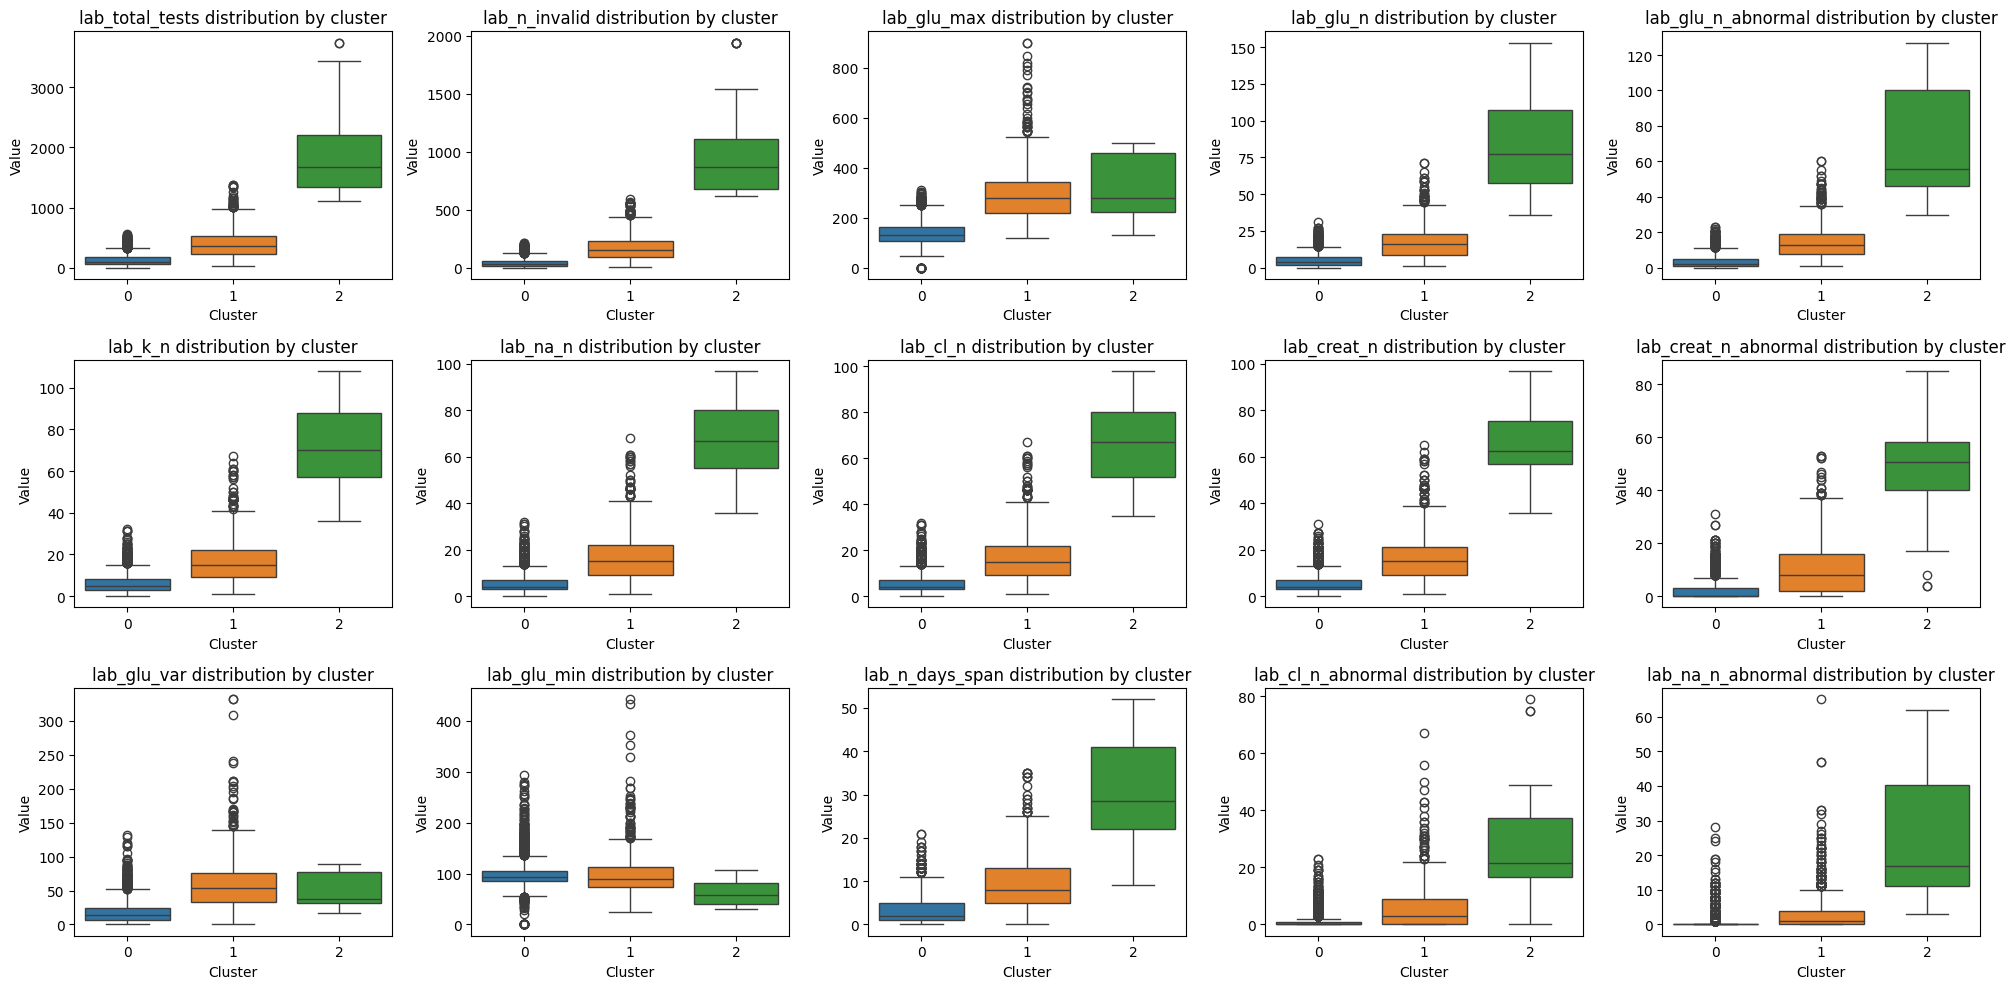

In [ ]:
# Select top 15 features
top_features = important_features.index[:15]

# Create subplots: 3 rows, 5 columns (adjust as needed)
fig, axes = plt.subplots(3, 5, figsize=(20, 10))  # 3 rows, 5 columns

# Flatten axes to make indexing easier
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(top_features):
    sns.boxplot(x="cluster", y=col, data=df_clustered, hue="cluster", palette="tab10", ax=axes[i], legend=False)
    axes[i].set_title(f"{col} distribution by cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Value")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Cluster Interpretation and Clinical Meaning

### **What we are looking at**
The descriptive summaries show how each cluster differs based on measurable physiological and laboratory behavior rather than just algorithmic grouping. Each cluster reveals a level of patient "intensity" based on testing frequency, abnormality count, and monitoring duration.

---

### **<span style="color: #1f77b4;">Cluster 0</span> — Stable / Low Acuity Group**
- **Observations:**  
  - Very few lab tests (≈ 128 on average).  
  - Glucose and creatinine test counts, as well as abnormalities, are minimal.  
  - Short monitoring span (~3 days).  
- **Clinical meaning:**  
  Routine or low‑acuity admissions. Patients under short observation with almost normal lab trends — likely mild or stable chronic cases.

---

### **<span style="color: #ff7f0e;">Cluster 1</span> — Moderate Acuity / Medical Ward Group**
- **Observations:**  
  - Around 400 lab tests per patient.  
  - Monitoring extends to about 10 days.  
  - Noticeable rise in glucose (max ≈ 294 mg/dL) and creatinine abnormalities (~10 abnormal results).  
- **Clinical meaning:**  
  Patients exhibiting metabolic or renal stress. They represent an intermediate group requiring hospital management and ongoing laboratory follow‑up.

---

### **<span style="color: #2ca02c;">Cluster 2</span> — High Acuity / Critical Care Group**
- **Observations:**  
  - Extremely large test volume (> 2000 lab tests) and longest monitoring duration (~31 days).  
  - Highest counts of abnormal glucose and creatinine results.  
  - Greater number of procedural entries and microbiology records indicate complex or infection‑related management.  
- **Clinical meaning:**  
  Intensive‑care or multi‑organ failure patients requiring round‑the‑clock monitoring, repeated sampling, and multiple interventions.

---

### **Summary Table**

| Cluster | Key Numeric Findings | Probable Clinical Interpretation |
|---------|----------------------|----------------------------------|
| <span style="color: #1f77b4;">Cluster 0</span> | Lowest test volume, shortest duration, minimal abnormalities | Stable or minor issue patients |
| <span style="color: #ff7f0e;">Cluster 1</span> | Moderate testing load, elevated glucose + creatinine abnormalities | Medical-ward patients with metabolic or renal stress |
| <span style="color: #2ca02c;">Cluster 2</span> | Extremely high testing + procedure count, multiple abnormal labs | Critical-care or ICU-level patients needing intensive monitoring |

---

### **Concluding**
These clusters provide a clinically intuitive stratification:
- <span style="color: #1f77b4;">Cluster 0</span> → Stable, low-risk profiles  
- <span style="color: #ff7f0e;">Cluster 1</span> → Moderate burden patients  
- <span style="color: #2ca02c;">Cluster 2</span> → Severe / critical care cases  


# Step 6 | DBSCAN and Hierarchical Validation

### **What we are doing**
Use DBSCAN to detect natural density‑based groups and outliers.  
Use Ward hierarchical clustering to confirm that same 6‑cluster structure reappears.

### **Why we are doing it**
Confirms that patterns captured by K‑Means are not algorithm‑specific and exposes rare patient profiles automatically.

DBSCAN clusters: 8


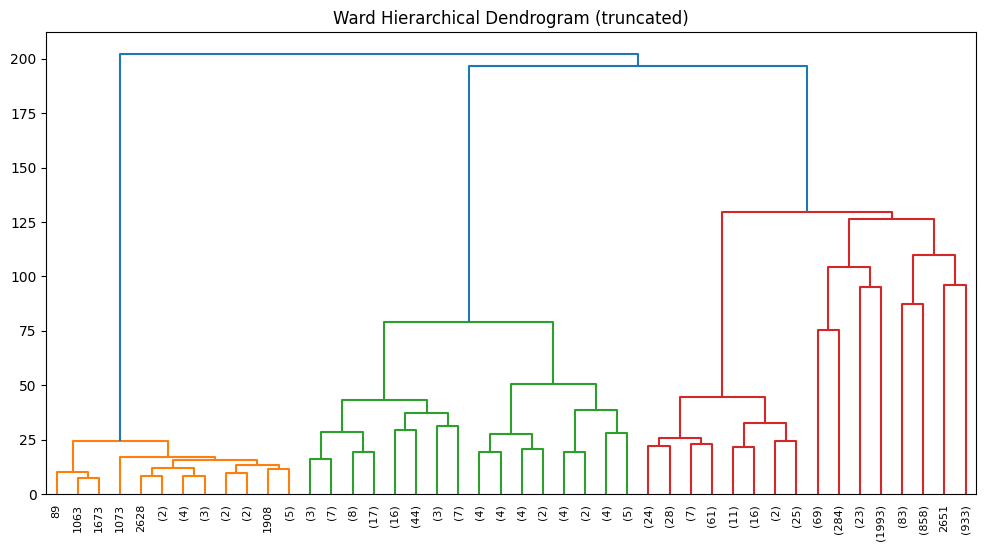

In [117]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# DBSCAN
db = DBSCAN(eps=1.0, min_samples=3)
lab_db = db.fit_predict(X_scaled)
print("DBSCAN clusters:", len(set(lab_db)) - (1 if -1 in lab_db else 0))

# Hierarchical (Ward)
link = linkage(X_scaled, method="ward")
plt.figure(figsize=(12,6))
dendrogram(link, truncate_mode="level", p=5)
plt.title("Ward Hierarchical Dendrogram (truncated)")
plt.show()

# Step 7 | Patient‑Level Outlier Detection

### **What we are doing**
Combining multiple methods (K‑Means distance, DBSCAN noise, Isolation Forest) to flag rare patients.

### **Why we are doing it**
Outliers often correspond to unusual but clinically important scenarios—multi‑organ failure, data errors, or rare pathologies—that require manual review.

Outliers: 92 / 4576


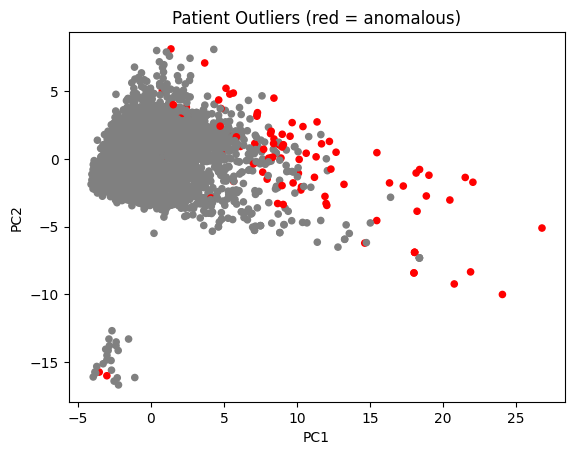

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42).fit(X_scaled)
scores = -iso.score_samples(X_scaled)
threshold = np.percentile(scores, 98)
outliers = scores > threshold
print("Outliers:", outliers.sum(), "/", len(outliers))

# Performing PCA for 2D visualization
pca = PCA(2)
red = pca.fit_transform(X_scaled)

# Creating color array for outliers (red) and normal points (grey)
colors = np.where(outliers, 'red', 'grey')

# Plotting the 2D projection of data with outliers marked
plt.scatter(red[:, 0], red[:, 1], c=colors, s=20)
plt.title("Patient Outliers (red = anomalous)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
